**ANOVA (Analysis of Variance)**

Example হিসেবে নিই তিনটি study environment-এ students-এর test scores:

Group A → Quiet Room
Group B → Group Study
Group C → Online Study

আমাদের question:

তিনটি group's average score কি একই, নাকি অন্তত একটি group-এর mean আলাদা?

**One-Way ANOVA**

In [15]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [16]:
group_A = [72, 75, 71, 69, 74, 76, 73, 70, 77, 72]

group_B = [80, 82, 78, 85, 81, 83, 79, 84, 80, 82]

group_C = [74, 76, 73, 77, 75, 72, 78, 74, 76, 75]

In [17]:
df = pd.DataFrame({
    "Quiet_Room": group_A,
    "Group_Study": group_B,
    "Online_Study": group_C
})

df.head()

,Quiet_Room,Group_Study,Online_Study
0,72,80,74
1,75,82,76
2,71,78,73
3,69,85,77
4,74,81,75


**Descriptive Statistics**


In [18]:
df.describe()

,Quiet_Room,Group_Study,Online_Study
count,10.000000,10.000000,10.000000
mean,72.900000,81.400000,75.000000
std,2.601282,2.221111,1.825742
min,69.000000,78.000000,72.000000
25%,71.250000,80.000000,74.000000
50%,72.500000,81.500000,75.000000
75%,74.750000,82.750000,76.000000
max,77.000000,85.000000,78.000000


In [19]:
print("Quiet Room Mean:", df["Quiet_Room"].mean())
print("Group Study Mean:", df["Group_Study"].mean())
print("Online Study Mean:", df["Online_Study"].mean())

Quiet Room Mean: 72.9
Group Study Mean: 81.4
Online Study Mean: 75.0


In [20]:
print("Quiet Room SD:", df["Quiet_Room"].std())
print("Group Study SD:", df["Group_Study"].std())
print("Online Study SD:", df["Online_Study"].std())

Quiet Room SD: 2.6012817353502227
Group Study SD: 2.2211108331943574
Online Study SD: 1.8257418583505538


/tmp/ipykernel_4094/801133309.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


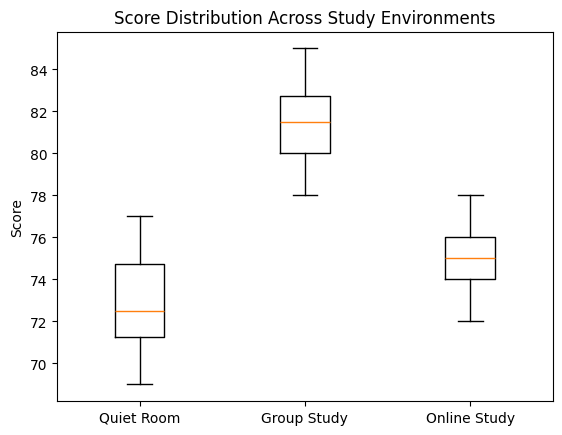

In [21]:
plt.boxplot(
    [group_A, group_B, group_C],
    labels=["Quiet Room", "Group Study", "Online Study"]
)

plt.ylabel("Score")
plt.title("Score Distribution Across Study Environments")

plt.show()

Hypothesis
H₀

তিন group-এর population mean একই।

μA = μB = μC
H₁

সব mean একই নয়।



ANOVA-এর H₁ বলছে না যে A ≠ B ≠ C সবগুলো।

শুধু বলছে:

At least one group mean is different.

**One-Way ANOVA**

In [22]:
f_stat, p_value = stats.f_oneway(
    group_A,
    group_B,
    group_C
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 39.11973392461191
p-value: 1.0568153934494557e-08


In [23]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


অর্থাৎ তিনটি group's mean একই—এমন assumption-এর বিরুদ্ধে statistically significant evidence আছে।

তাহলে আমরা জানলাম:

অন্তত একটি group আলাদা।

কিন্তু জানলাম না:

A vs B ?
A vs C ?
B vs C ?

এটা জানার জন্য Post-hoc test করতে হবে।//

**Tukey HSD Post-hoc Test**

In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
scores = group_A + group_B + group_C

groups = (
    ["Quiet Room"] * len(group_A) +
    ["Group Study"] * len(group_B) +
    ["Online Study"] * len(group_C)
)

anova_df = pd.DataFrame({
    "score": scores,
    "group": groups
})

anova_df.head()

,score,group
0,72,Quiet Room
1,75,Quiet Room
2,71,Quiet Room
3,69,Quiet Room
4,74,Quiet Room


**Tukey Test**

In [25]:
tukey = pairwise_tukeyhsd(
    endog=anova_df["score"],
    groups=anova_df["group"],
    alpha=0.05
)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
 Group Study Online Study     -6.4    0.0  -8.8822 -3.9178   True
 Group Study   Quiet Room     -8.5    0.0 -10.9822 -6.0178   True
Online Study   Quiet Room     -2.1 0.1092  -4.5822  0.3822  False
-----------------------------------------------------------------


যদি:

reject = True

তাহলে ঐ pair-এর difference statistically significant।

যদি:

reject = False

তাহলে significant difference-এর sufficient evidence নেই।

**ANOVA Assumptions**

ANOVA করার আগে তিনটা important assumption মাথায় রাখবে:

① Independence

Observations independent হতে হবে।

② Normality

প্রতিটি group's residual/data approximately normal হওয়া উচিত।

③ Homogeneity of variance

**Normality Check**

In [26]:
print("Group A:", stats.shapiro(group_A))
print("Group B:", stats.shapiro(group_B))
print("Group C:", stats.shapiro(group_C))

Group A: ShapiroResult(statistic=np.float64(0.9752339025839644), pvalue=np.float64(0.9346854448707653))
Group B: ShapiroResult(statistic=np.float64(0.977982777888741), pvalue=np.float64(0.9534645301298255))
Group C: ShapiroResult(statistic=np.float64(0.9837162715136384), pvalue=np.float64(0.9819299383121683))


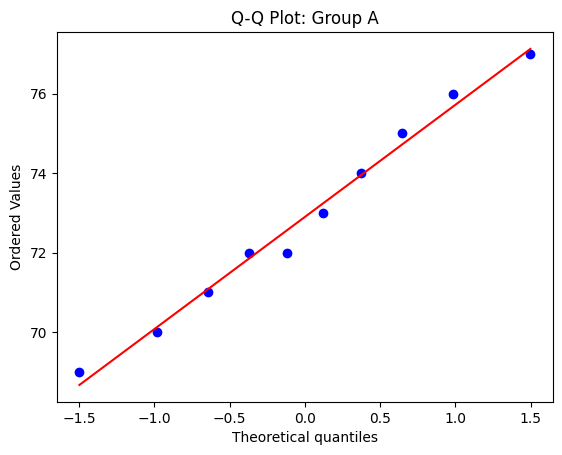

In [27]:
stats.probplot(group_A, dist="norm", plot=plt)
plt.title("Q-Q Plot: Group A")
plt.show()

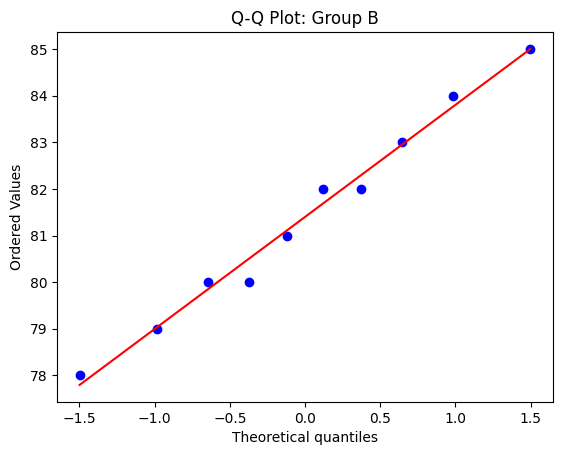

In [28]:
stats.probplot(group_B, dist="norm", plot=plt)
plt.title("Q-Q Plot: Group B")
plt.show()

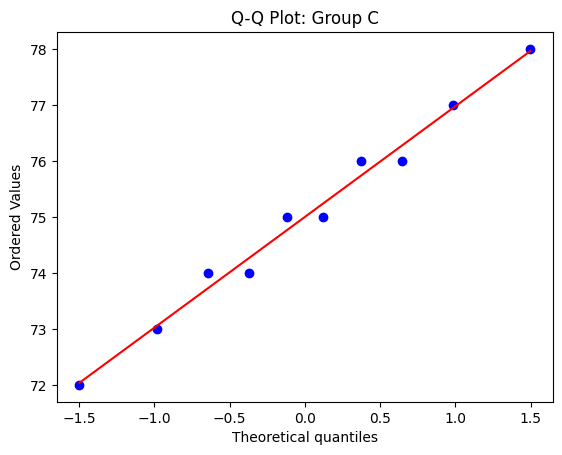

In [29]:
stats.probplot(group_C, dist="norm", plot=plt)
plt.title("Q-Q Plot: Group C")
plt.show()

**Equal Variance Check**

In [30]:
levene_stat, levene_p = stats.levene(
    group_A,
    group_B,
    group_C
)

print("Levene statistic:", levene_stat)
print("p-value:", levene_p)

Levene statistic: 0.8141809290953548
p-value: 0.45358438293292175


সাধারণভাবে:

p > 0.05

হলে equal variance assumption-এর বিরুদ্ধে strong evidence নেই।

**Effect Size — Eta Squared**

In [31]:
all_scores = np.concatenate([
    group_A,
    group_B,
    group_C
])

grand_mean = np.mean(all_scores)

ss_between = (
    len(group_A) * (np.mean(group_A) - grand_mean)**2 +
    len(group_B) * (np.mean(group_B) - grand_mean)**2 +
    len(group_C) * (np.mean(group_C) - grand_mean)**2
)

ss_total = np.sum(
    (all_scores - grand_mean)**2
)

eta_squared = ss_between / ss_total

print("Eta Squared:", eta_squared)

Eta Squared: 0.7434422602869605


Group A Mean: 72.9
Group B Mean: 81.4
Group C Mean: 75.0

Group A SD: 2.6012817353502227
Group B SD: 2.2211108331943574
Group C SD: 1.8257418583505538


/tmp/ipykernel_4094/270549550.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


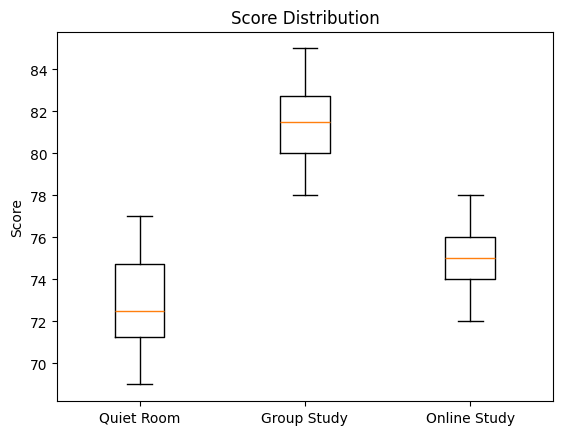


F-statistic: 39.11973392461191
p-value: 1.0568153934494557e-08
Reject H0

Tukey HSD:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
 Group Study Online Study     -6.4    0.0  -8.8822 -3.9178   True
 Group Study   Quiet Room     -8.5    0.0 -10.9822 -6.0178   True
Online Study   Quiet Room     -2.1 0.1092  -4.5822  0.3822  False
-----------------------------------------------------------------

Levene test p-value: 0.45358438293292175
Eta Squared: 0.7434422602869605


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# -------------------------
# 1. Data
# -------------------------

group_A = [72, 75, 71, 69, 74, 76, 73, 70, 77, 72]

group_B = [80, 82, 78, 85, 81, 83, 79, 84, 80, 82]

group_C = [74, 76, 73, 77, 75, 72, 78, 74, 76, 75]


# -------------------------
# 2. Descriptive statistics
# -------------------------

print("Group A Mean:", np.mean(group_A))
print("Group B Mean:", np.mean(group_B))
print("Group C Mean:", np.mean(group_C))

print("\nGroup A SD:", np.std(group_A, ddof=1))
print("Group B SD:", np.std(group_B, ddof=1))
print("Group C SD:", np.std(group_C, ddof=1))


# -------------------------
# 3. Visualization
# -------------------------

plt.boxplot(
    [group_A, group_B, group_C],
    labels=["Quiet Room", "Group Study", "Online Study"]
)

plt.ylabel("Score")
plt.title("Score Distribution")
plt.show()


# -------------------------
# 4. One-way ANOVA
# -------------------------

f_stat, p_value = stats.f_oneway(
    group_A,
    group_B,
    group_C
)

print("\nF-statistic:", f_stat)
print("p-value:", p_value)


# -------------------------
# 5. Decision
# -------------------------

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")


# -------------------------
# 6. Prepare long-format data
# -------------------------

scores = group_A + group_B + group_C

groups = (
    ["Quiet Room"] * len(group_A) +
    ["Group Study"] * len(group_B) +
    ["Online Study"] * len(group_C)
)

anova_df = pd.DataFrame({
    "score": scores,
    "group": groups
})


# -------------------------
# 7. Tukey HSD
# -------------------------

tukey = pairwise_tukeyhsd(
    endog=anova_df["score"],
    groups=anova_df["group"],
    alpha=0.05
)

print("\nTukey HSD:")
print(tukey)


# -------------------------
# 8. Levene's test
# -------------------------

levene_stat, levene_p = stats.levene(
    group_A,
    group_B,
    group_C
)

print("\nLevene test p-value:", levene_p)


# -------------------------
# 9. Eta squared
# -------------------------

all_scores = np.concatenate([
    group_A,
    group_B,
    group_C
])

grand_mean = np.mean(all_scores)

ss_between = sum([
    len(group_A) * (np.mean(group_A) - grand_mean)**2,
    len(group_B) * (np.mean(group_B) - grand_mean)**2,
    len(group_C) * (np.mean(group_C) - grand_mean)**2
])

ss_total = np.sum(
    (all_scores - grand_mean)**2
)

eta_squared = ss_between / ss_total

print("Eta Squared:", eta_squared)